# Energy Efficienty EDA



# Intro Analysis Thoughts 
---
After performing a very basic research regarding my dataset to find my target variables as well as clarify the prediction objective. I have found concluded a few aspects regarding my information. 
- Heating Load (Y1) (predictors): This is the energy required to maintain indoor temperatures during cold conditions
- Cooling Load (Y2) (predictors): This is the energy require to maintain indoor temperatures during hot conditions
---
# Goal
After reviewing the beginning of the data I see that my goal is to determine how specific architectural characterstics influence the energy efficiency of a structure. I am to predict the Y1 and Y2 to identify which design parameters are most responsible for energy waste. In doing so I will be able to provide recommendations on which building shapes minimize energy consumption. 

---
The first step for EDA is to import the appropriate packages that I will be using an alias them accordingly. These packages include pandas, numpy, matplotlib.pyplot, and seaborn. 

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 

from scipy import stats

Loading my dataframe
I will be using df_e for the data sample of the Energy Efficiency.

In [2]:
df_e = pd.read_csv('../datasets/ENB2012_data.csv')

First I want to remind myself of the data that I have to explore. 

In [5]:
df_e.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X1      768 non-null    float64
 1   X2      768 non-null    float64
 2   X3      768 non-null    float64
 3   X4      768 non-null    float64
 4   X5      768 non-null    float64
 5   X6      768 non-null    int64  
 6   X7      768 non-null    float64
 7   X8      768 non-null    int64  
 8   Y1      768 non-null    float64
 9   Y2      768 non-null    float64
dtypes: float64(8), int64(2)
memory usage: 60.1 KB


Now I want to check the shape of my data frame

In [14]:
print("Energy Efficiency Data shape:" , df_e.shape)

Energy Efficiency Data shape: (768, 10)


Now before I continue my anlysis I was informed that there are no missing variables but I want to double check in case of any error. After performing this it is good to know that there is no data missing. 

In [13]:
print("Displaying any missing values")
df_e.isnull().sum()

Displaying any missing values


X1    0
X2    0
X3    0
X4    0
X5    0
X6    0
X7    0
X8    0
Y1    0
Y2    0
dtype: int64

In [12]:
print("First 10 Rows")
display(df_e.head(10))

First 10 Rows


,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28
5,0.90,563.5,318.5,122.50,7.0,3,0.0,0,21.46,25.38
6,0.90,563.5,318.5,122.50,7.0,4,0.0,0,20.71,25.16
7,0.90,563.5,318.5,122.50,7.0,5,0.0,0,19.68,29.60
8,0.86,588.0,294.0,147.00,7.0,2,0.0,0,19.50,27.30
9,0.86,588.0,294.0,147.00,7.0,3,0.0,0,19.95,21.97


In [11]:
print("Last 10 Rows")
display(df_e.tail(10))

Last 10 Rows


,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
758,0.66,759.5,318.5,220.5,3.5,4,0.4,5,14.92,17.55
759,0.66,759.5,318.5,220.5,3.5,5,0.4,5,15.16,18.06
760,0.64,784.0,343.0,220.5,3.5,2,0.4,5,17.69,20.82
761,0.64,784.0,343.0,220.5,3.5,3,0.4,5,18.19,20.21
762,0.64,784.0,343.0,220.5,3.5,4,0.4,5,18.16,20.71
763,0.64,784.0,343.0,220.5,3.5,5,0.4,5,17.88,21.40
764,0.62,808.5,367.5,220.5,3.5,2,0.4,5,16.54,16.88
765,0.62,808.5,367.5,220.5,3.5,3,0.4,5,16.44,17.11
766,0.62,808.5,367.5,220.5,3.5,4,0.4,5,16.48,16.61
767,0.62,808.5,367.5,220.5,3.5,5,0.4,5,16.64,16.03


In [ ]:
print("Columns for the Dataset", df_e.columns)

Index(['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'Y1', 'Y2'], dtype='object')

Here I am checking the data types of the variables

In [15]:
print("These are the data types for the dataset columns")
display(df_e.dtypes)

These are the data types for the dataset columns


X1    float64
X2    float64
X3    float64
X4    float64
X5    float64
X6      int64
X7    float64
X8      int64
Y1    float64
Y2    float64
dtype: object

In [16]:
print("Energy Data")
display(df_e.describe())

Energy Data


,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
count,768.000000,768.000000,768.000000,768.000000,768.00000,768.000000,768.000000,768.00000,768.000000,768.000000
mean,0.764167,671.708333,318.500000,176.604167,5.25000,3.500000,0.234375,2.81250,22.307201,24.587760
std,0.105777,88.086116,43.626481,45.165950,1.75114,1.118763,0.133221,1.55096,10.090196,9.513306
min,0.620000,514.500000,245.000000,110.250000,3.50000,2.000000,0.000000,0.00000,6.010000,10.900000
25%,0.682500,606.375000,294.000000,140.875000,3.50000,2.750000,0.100000,1.75000,12.992500,15.620000
50%,0.750000,673.750000,318.500000,183.750000,5.25000,3.500000,0.250000,3.00000,18.950000,22.080000
75%,0.830000,741.125000,343.000000,220.500000,7.00000,4.250000,0.400000,4.00000,31.667500,33.132500
max,0.980000,808.500000,416.500000,220.500000,7.00000,5.000000,0.400000,5.00000,43.100000,48.030000


After my initial inspection of the data I want to get a better look at the information and ask a few questions regarding the data in order to find more information about what would be the best building shape. 

First I want to find out what is the distribution of the primary predictor which is Heating Load.

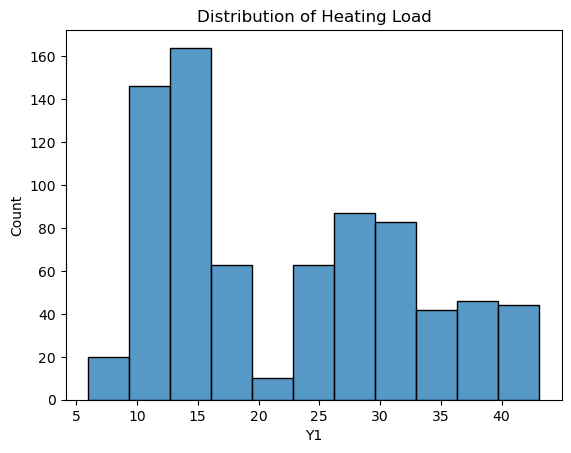

In [ ]:
sns.histplot(data = df_e, x = 'Y1')
plt.xlabel('Heating Load')
plt.title('Distribution of Heating Load')
plt.show()

Next I want to see what is the primary target for the second predictor which is Cooling Load.

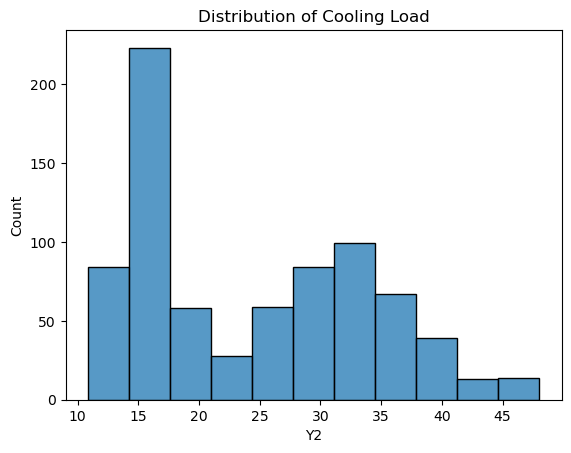

In [19]:
sns.histplot(data = df_e, x = 'Y2')
plt.title('Distribution of Cooling Load')
plt.show()

I want to see the difference between the two charts side by side for a better view of the data. 

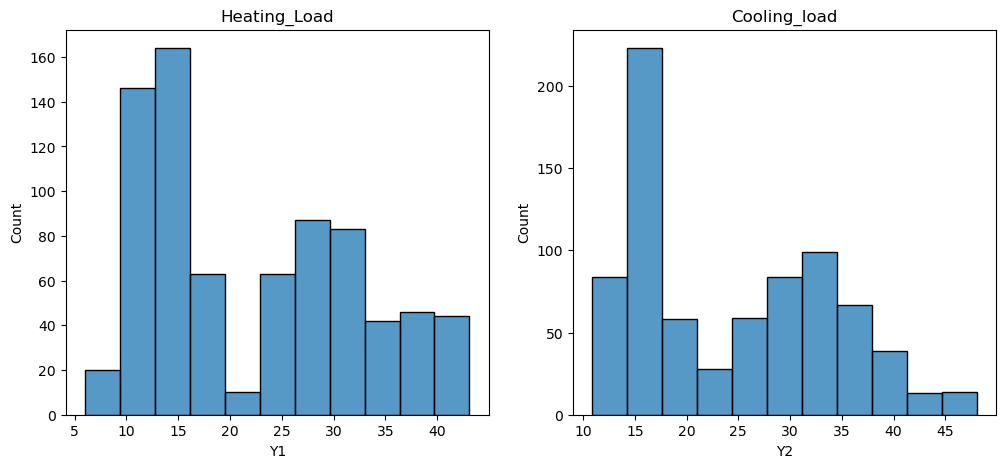

In [26]:
fig, axes = plt.subplots(1, 2, figsize = (12, 5))
sns.histplot(data = df_e, x = 'Y1', ax = axes[0])
sns.histplot(data = df_e, x = 'Y2', ax = axes[1])
axes[0].set_title('Heating_Load')
axes[1].set_title('Cooling_load')
plt.show()


Does building orientation affect energy efficiency. 

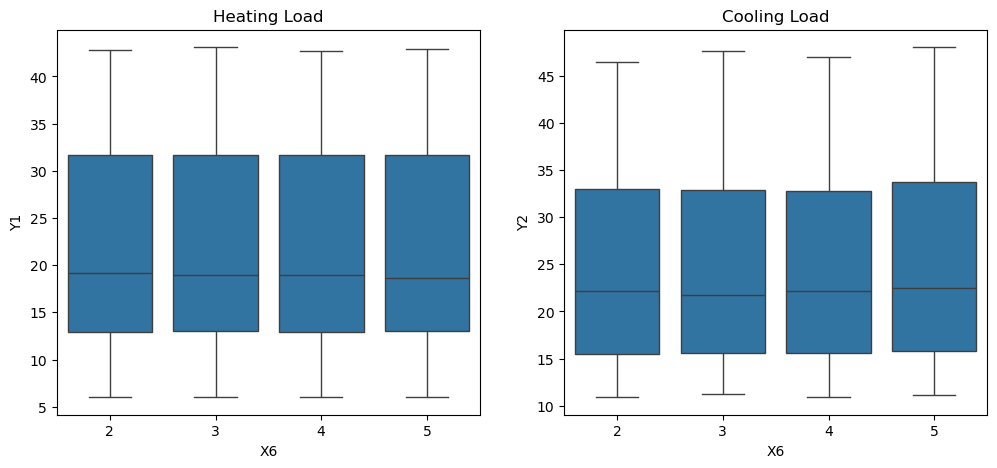

In [30]:
fig, axes = plt.subplots(1, 2, figsize = (12, 5))
sns.boxplot(data = df_e, x = 'X6', y = 'Y1', ax = axes[0])
sns.boxplot(data = df_e, x = 'X6', y = 'Y2', ax = axes[1])
axes[0].set_title("Heating Load")
axes[1].set_title("Cooling Load")
plt.show()




Does building height affect energy efficiency? 

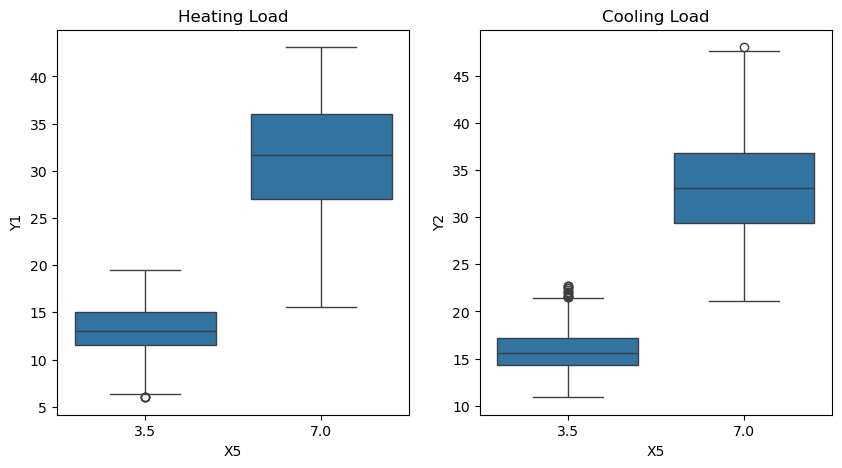

In [35]:
fig, axes = plt.subplots(1, 2, figsize = (10, 5))
sns.boxplot(data = df_e, x = 'X5', y = 'Y1', ax = axes[0])
sns.boxplot(data = df_e, x = 'X5', y = 'Y2', ax = axes[1])
axes[0].set_title('Heating Load')
axes[1].set_title('Cooling Load')
plt.show()




Does window placement across walls affect energy loads? 

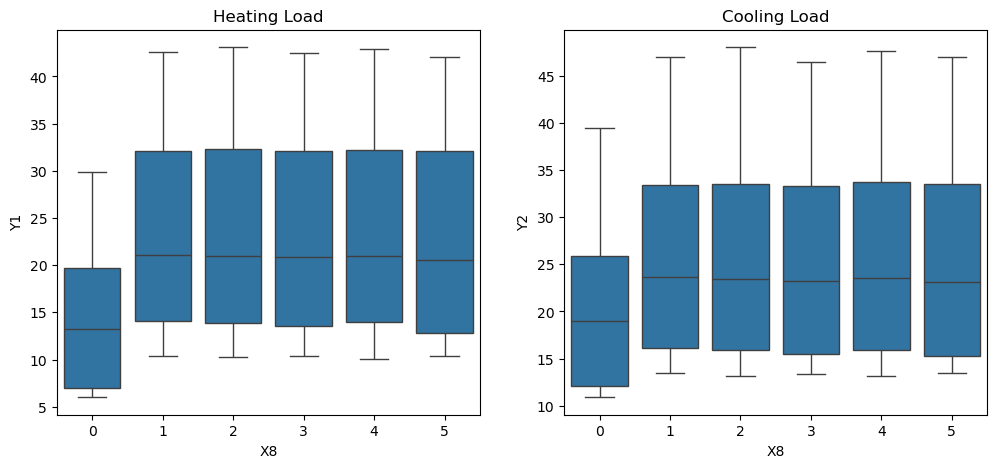

In [38]:
fig, axes = plt.subplots(1, 2, figsize = (12,5))
sns.boxplot(data = df_e, x = 'X8', y = 'Y1', ax = axes[0])
sns.boxplot(data = df_e, x = 'X8', y = 'Y2', ax = axes[1])
axes[0].set_title("Heating Load")
axes[1].set_title("Cooling Load")
plt.show()

How is glazing area distributed.

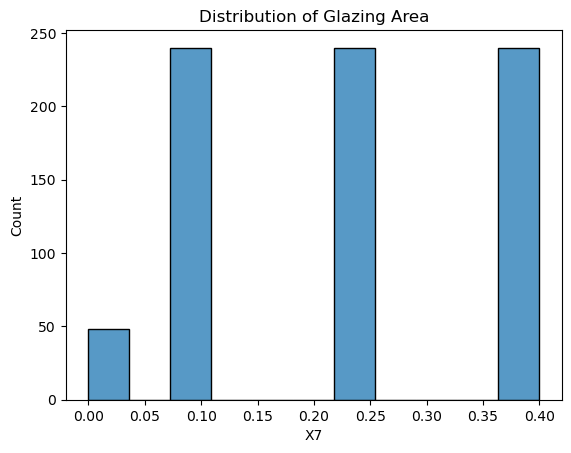

In [39]:
sns.histplot(data = df_e, x = 'X7')
plt.title('Distribution of Glazing Area')
plt.show()

Do buildings with more glazing area tend to have higher cooling loads?

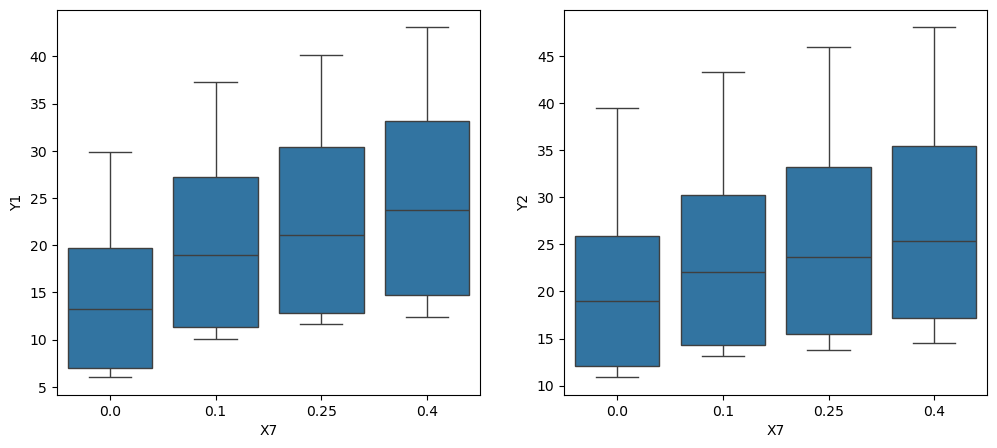

In [40]:
fig, axes = plt.subplots(1, 2, figsize = (12, 5))
sns.boxplot(data = df_e, x = 'X7', y = 'Y1', ax = axes[0])
sns.boxplot(data = df_e, x = 'X7', y = 'Y2', ax = axes[1])
plt.show()

Is there multicollinerity between compactness and surface area?

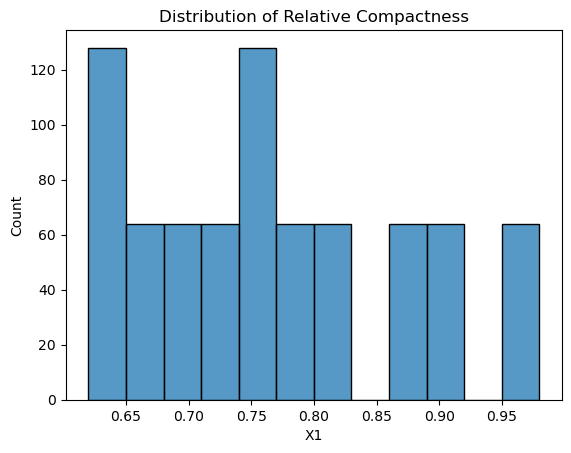

In [41]:
sns.histplot(data = df_e, x = 'X1')
plt.title('Distribution of Relative Compactness')
plt.show()